MOUNT GOOGLE DRIVE

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DEFINE DATASET PATH

In [10]:
from pathlib import Path

DATASET_PATH = Path(
    "/content/drive/My Drive/chest_xray"
)

print("Dataset Path Loaded Successfully")

Dataset Path Loaded Successfully


In [11]:
import os
from pathlib import Path

print(f"Attempting to access: {DATASET_PATH}")

# Check if the DATASET_PATH exists
if not DATASET_PATH.exists():
    print(f"Error: The dataset path '{DATASET_PATH}' does not exist.")
    print("Please verify that the dataset is uploaded to your Google Drive and the path is correct.")
    print("You might want to check the contents of your Google Drive 'My Drive' folder:")
    try:
        my_drive_path = Path("/content/drive/My Drive")
        if my_drive_path.exists():
            print(f"Contents of '{my_drive_path}': {os.listdir(my_drive_path)}")
        else:
            print(f"Warning: '{my_drive_path}' also does not exist. Google Drive might not be mounted correctly or is empty.")
    except Exception as e:
        print(f"Could not list contents of My Drive: {e}")
else:
    print(f"Contents of {DATASET_PATH}:")
    print(os.listdir(DATASET_PATH))

Attempting to access: /content/drive/My Drive/chest_xray
Contents of /content/drive/My Drive/chest_xray:
['val', 'test', 'train', '__MACOSX', 'chest_xray']


IMPORT REQUIRED LIBRARIES

In [12]:
# File System Handling
import os
from pathlib import Path
from glob import glob

# Image Processing
import cv2
from PIL import Image

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Random Sampling
import random

VERIFY DATASET STRUCTURE

In [13]:
splits = ['train', 'test', 'val']
classes = ['NORMAL', 'PNEUMONIA']

print("="*50)
print("DATASET STRUCTURE VERIFICATION")
print("="*50)
for split in splits:
    split_path = DATASET_PATH / split
    if split_path.exists():
        print(f"\n {split.upper()} folder found")
        for cls in classes:
            class_path = split_path / cls
            if class_path.exists():
                total_images = len(glob(str(class_path / "*")))
                print(f"   |-- {cls:<12}: {total_images} images")
            else:
                print(f"   |-- Missing class folder: {cls}")
    else:
        print(f"\nMissing split folder: {split}")

DATASET STRUCTURE VERIFICATION

 TRAIN folder found
   |-- NORMAL      : 1341 images
   |-- PNEUMONIA   : 3875 images

 TEST folder found
   |-- NORMAL      : 234 images
   |-- PNEUMONIA   : 390 images

 VAL folder found
   |-- NORMAL      : 8 images
   |-- PNEUMONIA   : 8 images


COUNT TOTAL IMAGES

In [14]:
dataset_summary = []
for split in splits:
    for cls in classes:
        folder_path = DATASET_PATH / split / cls
        image_files = glob(str(folder_path / "*"))
        dataset_summary.append({
            "Dataset Split": split,
            "Class": cls,
            "Total Images": len(image_files)
        })
summary_df = pd.DataFrame(dataset_summary)
print("\nDATASET SUMMARY\n")
display(summary_df)


DATASET SUMMARY



,Dataset Split,Class,Total Images
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,test,NORMAL,234
3,test,PNEUMONIA,390
4,val,NORMAL,8
5,val,PNEUMONIA,8


VALIDATE DATASET INTEGRITY

In [15]:
corrupted_files = []
zero_byte_files = []
print("\nChecking Dataset Integrity...\n")
for split in splits:
    for cls in classes:
        folder_path = DATASET_PATH / split / cls
        image_files = glob(str(folder_path / "*"))
        for image_path in image_files:
            try:
                # Check zero-byte files
                if os.path.getsize(image_path) == 0:
                    zero_byte_files.append(image_path)
                    continue
                # Verify image validity
                with Image.open(image_path) as img:
                    img.verify()
            except Exception:
                corrupted_files.append(image_path)
print("="*50)
print("DATASET VALIDATION REPORT")
print("="*50)
print(f"Corrupted Images : {len(corrupted_files)}")
print(f"Zero-byte Images : {len(zero_byte_files)}")


Checking Dataset Integrity...

DATASET VALIDATION REPORT
Corrupted Images : 0
Zero-byte Images : 0


DISPLAY CORRUPTED FILES

In [16]:
if corrupted_files:
    print("\nSample Corrupted Files:\n")
    for file in corrupted_files[:5]:
        print(file)
else:
    print("No corrupted files found.")

No corrupted files found.


Load Random Sample Images


In [17]:
sample_images = []
# Number of images per class
images_per_class = 3
for cls in classes:
    folder_path = DATASET_PATH / "train" / cls
    image_files = glob(str(folder_path / "*"))
    # Select random images
    random_samples = random.sample(
        image_files,
        images_per_class
    )
    for image_path in random_samples:
        sample_images.append((cls, image_path))
print(f"Total Sample Images Loaded: {len(sample_images)}")


Total Sample Images Loaded: 6


Extract Image Metadata

In [18]:
metadata = []

for label, image_path in sample_images:
    # Read image using PIL
    pil_img = Image.open(image_path)
    # Read image using OpenCV
    cv_img = cv2.imread(image_path)
    width, height = pil_img.size
    channels = cv_img.shape[2] if len(cv_img.shape) == 3 else 1
    metadata.append({
        "Class": label,
        "Filename": os.path.basename(image_path),
        "Width": width,
        "Height": height,
        "Channels": channels,
        "Format": pil_img.format
    })

metadata_df = pd.DataFrame(metadata)
print("\nIMAGE METADATA\n")
display(metadata_df)


IMAGE METADATA



,Class,Filename,Width,Height,Channels,Format
0,NORMAL,IM-0627-0001.jpeg,1802,1514,3,JPEG
1,NORMAL,IM-0570-0001.jpeg,1816,1554,3,JPEG
2,NORMAL,IM-0672-0001.jpeg,2018,1920,3,JPEG
3,PNEUMONIA,person515_bacteria_2189.jpeg,1008,552,3,JPEG
4,PNEUMONIA,person1715_bacteria_4532.jpeg,1216,984,3,JPEG
5,PNEUMONIA,person1617_bacteria_4255.jpeg,944,440,3,JPEG


Display Sample Images

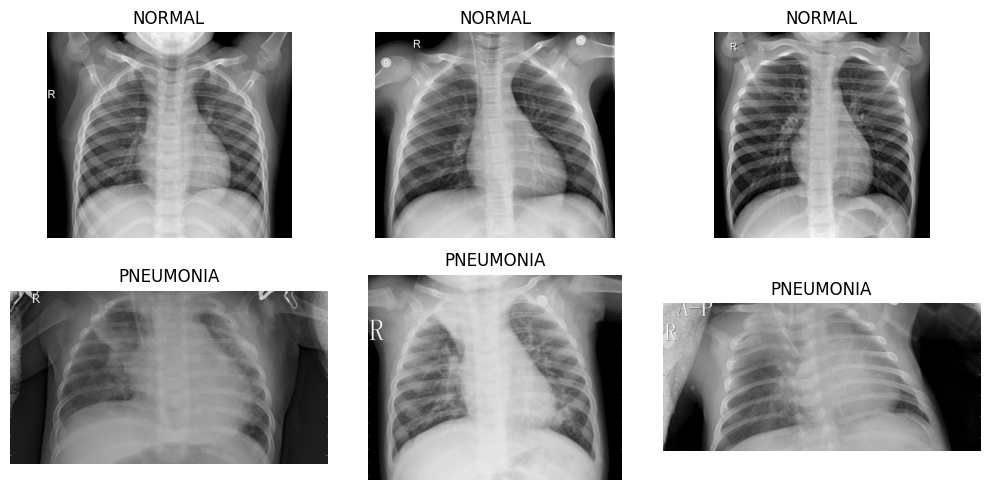

In [19]:
plt.figure(figsize=(10,5))
for i, (label, image_path) in enumerate(sample_images):
    img = Image.open(image_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()

Save Reports

In [20]:
# Create reports folder
os.makedirs("reports", exist_ok=True)
# Save CSV files
summary_df.to_csv("reports/dataset_summary.csv", index=False)
metadata_df.to_csv("reports/image_metadata.csv", index=False)
print("Reports saved successfully.")

Reports saved successfully.


In [21]:
summary_df.to_json(
    "dataset_summary.json",
    orient="records"
)

In [22]:
metadata_df.to_json(
    "image_metadata.json",
    orient="records"
)